# AQCtensor — Algorithm 1 (arXiv:2301.08609)

Building the AQCtensor algorithm end to end: exact ground truth, second-order Trotter circuit, a trainable brickwork AQC ansatz, exact Trotter-init, a cost function and optimizer, an MPS-native fidelity that scales past what a full `Statevector` can hold, and a from-scratch TEBD implementation verified against exact diagonalization and run at `L=50`. Steps 1-10 below build and verify each piece; the final markdown cell tracks what's still needed to run the whole pipeline together at scale.

In [1]:
import numpy as np
from scipy.linalg import expm
from qiskit.quantum_info import SparsePauliOp, Statevector

## Step 1 — ground truth: exact Hamiltonian + exact time evolution

Build the `H_XYZ` Hamiltonian and compute the exact time-evolved state via direct matrix exponentiation (`expm`). This is the ground truth every later approximation (Trotter circuit, AQC ansatz, TEBD) gets checked against — no shortcuts, just the real answer, only feasible while `L` is small.

In [2]:
def get_hamiltonian(L, alpha=1.0, beta=1.0, delta=1.0):
    #construct hamiltonian for the system
    pairs = [(i, i+1) for i in range(L-1)] # nearest neighbor pairs
    labels = []
    coeffs = []
    for i,j in pairs:
        for paulincoeff in [('X',alpha), ('Y',beta), ('Z',delta)]:
            pauli, coeff = paulincoeff
            pauli_string = ['I'] * L
            pauli_string[L-1-i] = pauli
            pauli_string[L-1-j] = pauli
            labels.append(''.join(pauli_string))
            coeffs.append(-0.25*coeff)
    return SparsePauliOp(labels, coeffs)

def get_Neel_State(L):
    # create a Neel state for a chain of length L it alternates like this 0101...
    thebits = ['01']*(L//2)
    print(''.join(thebits))
    return Statevector.from_label(''.join(thebits))

def timeevolution(H, psi, t):
    # evolve the state psi under Hamiltonian H for time t |ψ(t)⟩ = e^(-iHt/ℏ) |ψ(0)⟩ and we make ℏ=1 for simplicity
    U = expm(-1j * H.to_matrix() * t)
    return Statevector(U @ psi.data)

L=6
H = get_hamiltonian(L)
psi = get_Neel_State(L)
H_matrix = H.to_matrix()
print(H)
print(psi)
print("Time evolved state after t=1.0:")
print(timeevolution(H, psi, 1.0))


010101
SparsePauliOp(['IIIIXX', 'IIIIYY', 'IIIIZZ', 'IIIXXI', 'IIIYYI', 'IIIZZI', 'IIXXII', 'IIYYII', 'IIZZII', 'IXXIII', 'IYYIII', 'IZZIII', 'XXIIII', 'YYIIII', 'ZZIIII'],
              coeffs=[-0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j,
 -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j, -0.25+0.j,
 -0.25+0.j, -0.25+0.j, -0.25+0.j])
Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+

## Step 2 — the 2-qubit bond gate

Build the exact 2-qubit gate that implements time evolution under the `H_XYZ` term for one bond (one pair of neighboring qubits) — this is the basic building block every larger circuit (Trotter, AQC) is assembled from.

## Fig 3 block for 2 site operator as in paper

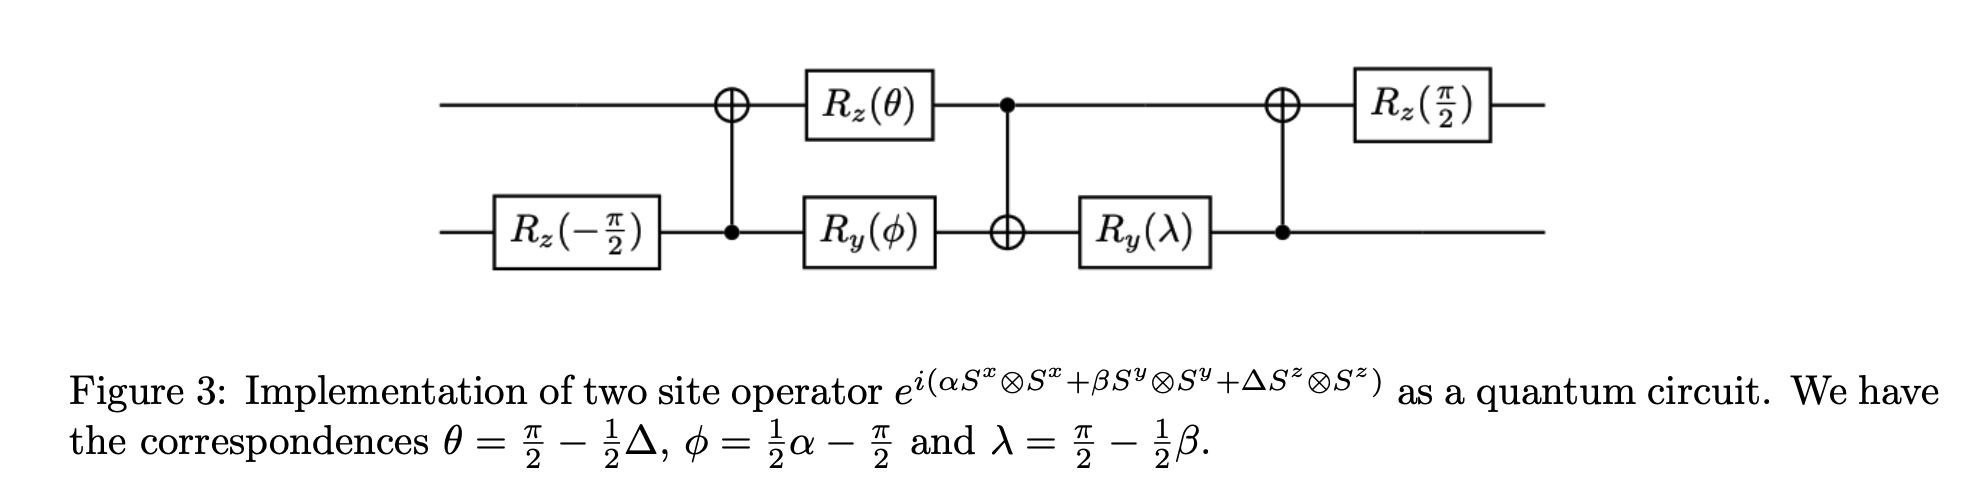

Bond gate for HXYZ:


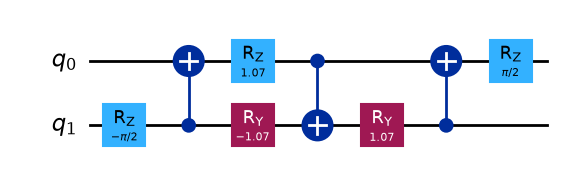

In [3]:
from math import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator

def get_bond_gate_for_hxyz(alpha=1.0, beta=1.0, delta=1.0):
    # bond as in between two atoms here it is 2 qubits. check the above diagram
    theta = pi/2 - 0.5*delta
    phi = 0.5*alpha -pi/2
    lam = pi/2 - 0.5*beta
    qc = QuantumCircuit(2)
    last_qubit = qc.num_qubits - 1
    qc.rz(-pi/2, last_qubit)
    qc.cx(last_qubit, 0)
    qc.rz(theta, 0)
    qc.ry(phi, last_qubit)
    qc.cx(0, last_qubit)
    qc.ry(lam, last_qubit)
    qc.cx(last_qubit, 0)
    qc.rz(pi/2, 0)
    return qc

def test_bond_gate_for_hxyz():
    qc = get_bond_gate_for_hxyz()
    U_circuit = Operator(qc)
    h_pair = SparsePauliOp(['XX', 'YY', 'ZZ'], [0.25, 0.25, 0.25])  # Hamiltonian for a pair of qubits
    U_target = expm(1j * h_pair.to_matrix() * 1.0)  # time evolution operator for t=1.0
    assert U_circuit.equiv(U_target), "The bond gate does not match the time evolution operator for HXYZ."

test_bond_gate_for_hxyz()
print("Bond gate for HXYZ:")
display(get_bond_gate_for_hxyz().draw('mpl'))



## Step 3 — second-order Trotter circuit

Chain bond gates (and field-layer rotations) together in the standard even/odd, half-step/half-step pattern to approximate time evolution of the *whole* chain. Accurate for short times/few steps, but circuit depth grows with time — this is exactly what the trainable AQC ansatz (next) is meant to replace with something shallower.

## Second order trotter circuit as in the paper as in Fig 4
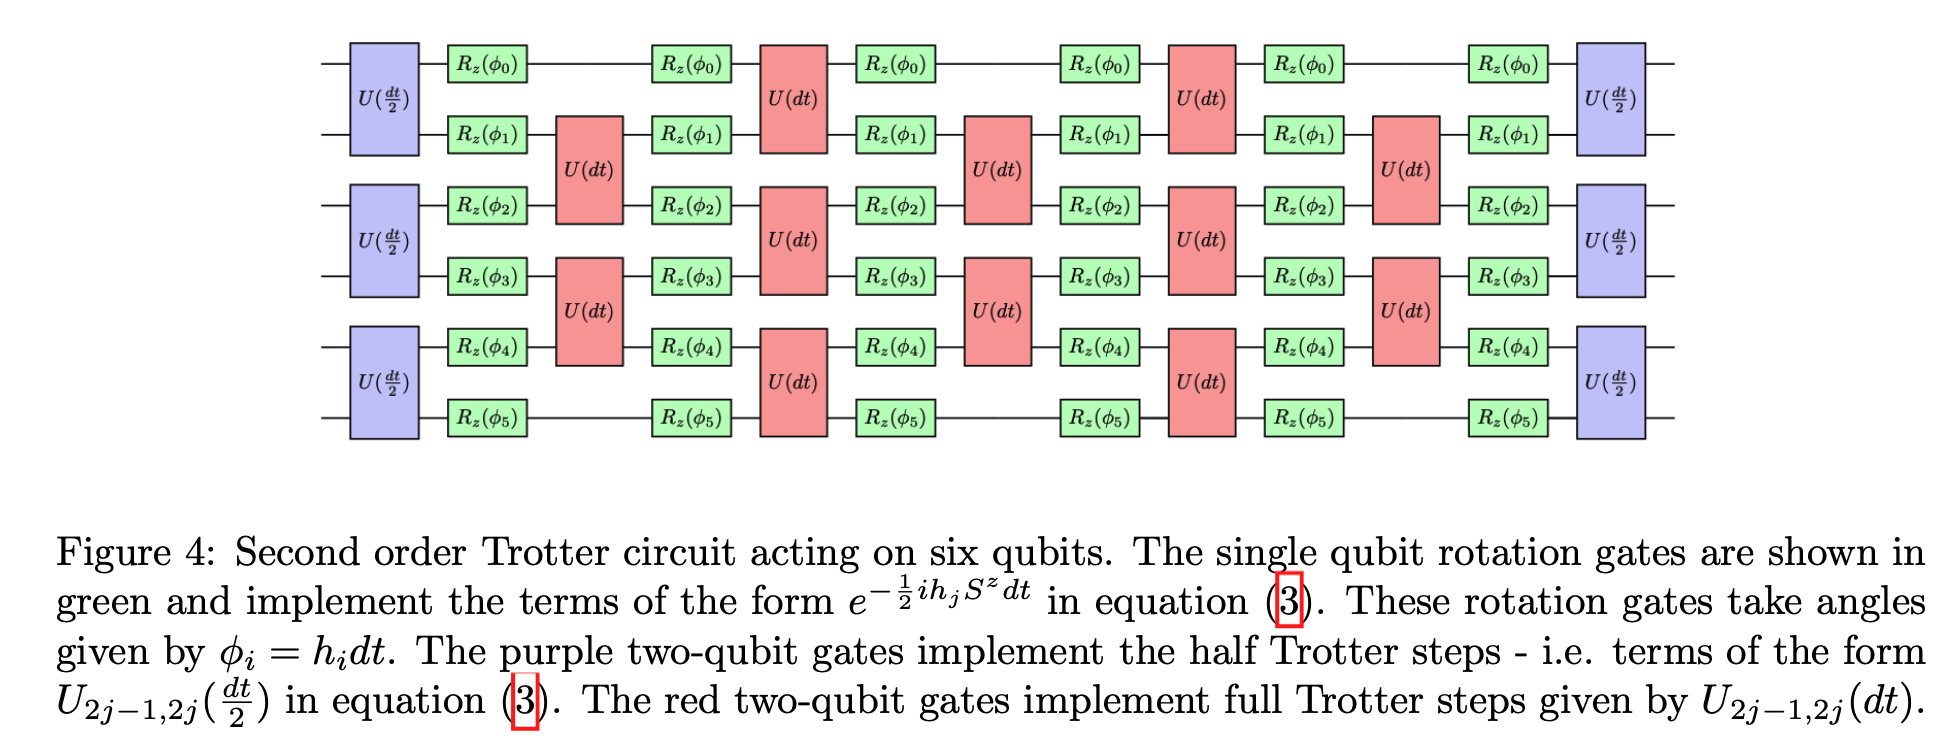

Second-order Trotter circuit for quantum state evolution with H_XYZ:


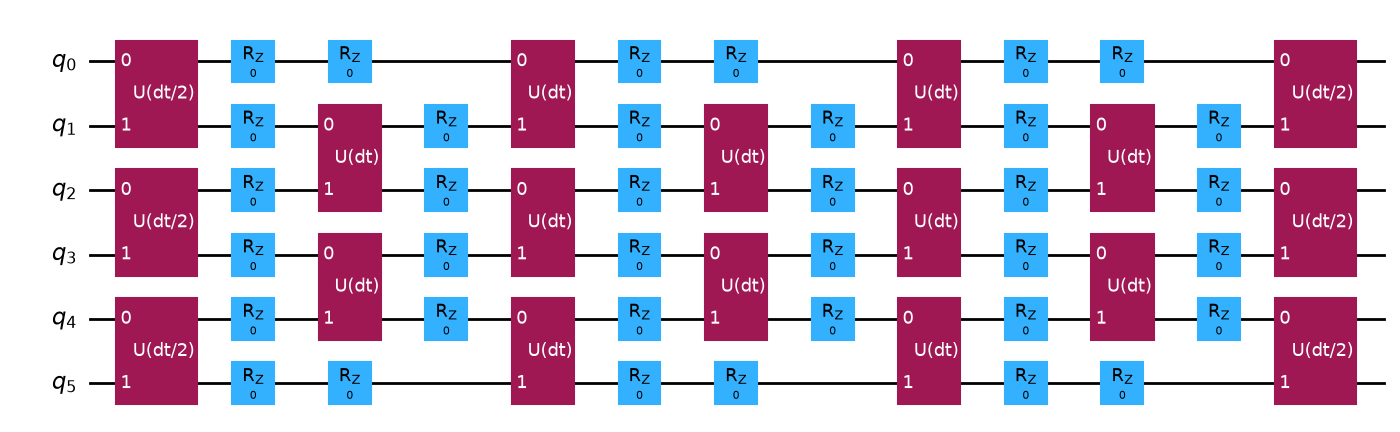

In [4]:
# lets build the second order circuit which creates the quantum state we want. this is efficient for short period of time but as time increases the circuit depth will increase and it will be inefficient. Then we will build the brickwork cricuit and use AQC to actually build the state we want. The brickwork circuit is more efficient for longer time evolution.

def second_order_trotter_circuit(L, alpha=1, beta=1, delta=1, t=1, steps=1, h=None):

    if h is None:
        h = [0] * L
    dt = t/steps
    even_pairs = [(i, i+1) for i in range(0, L-1, 2)]
    odd_pairs = [(i, i+1) for i in range(1, L-1, 2)] # note we start with 1 here

    def apply_bond_layer(qc, pairs, layer_dt, bond_gate_label):
        for i, j in pairs:
            bond_gate = get_bond_gate_for_hxyz(alpha*layer_dt, beta*layer_dt, delta*layer_dt).to_gate(label=bond_gate_label)
            qc.append(bond_gate, [i, j])

    def apply_field_layer(qc, h, dt):
        for q in range(L):
            qc.rz(h[q]*dt/2, q)

    qc = QuantumCircuit(L)
    apply_bond_layer(qc, even_pairs, dt/2, "U(dt/2)")
    for step in range(steps):
        apply_field_layer(qc, h, dt) 
        apply_bond_layer(qc, odd_pairs, dt, "U(dt)")
        apply_field_layer(qc, h, dt) 
        if step < steps -1:
            apply_bond_layer(qc, even_pairs, dt, "U(dt)")
        else:
            apply_bond_layer(qc, even_pairs, dt/2, "U(dt/2)")
    return qc

print("Second-order Trotter circuit for quantum state evolution with H_XYZ:")
display(second_order_trotter_circuit(6, alpha=1, beta=1, delta=1, t=1, steps=3).draw('mpl'))


## Step 4 — the trainable AQC ansatz (brickwork circuit)

Build the general, trainable circuit structure (init layer + triplet blocks + field layers) that AQC will optimize — same even/odd pair structure as the Trotter circuit, but with free parameters instead of physics-derived ones, so training can search for a shallower circuit that reproduces the same target state.

## Build the AQC building blocks
### Fig 7 in the paper
The triplet block isn't "the bond gate, dressed up" — it's "the most general possible 2-qubit gate," and the bond gate happens to be one very specific, restricted point inside that much bigger space (it only needs 3 real numbers — theta, phi, lam — because it comes from one very specific Hamiltonian; the triplet has room for 12).

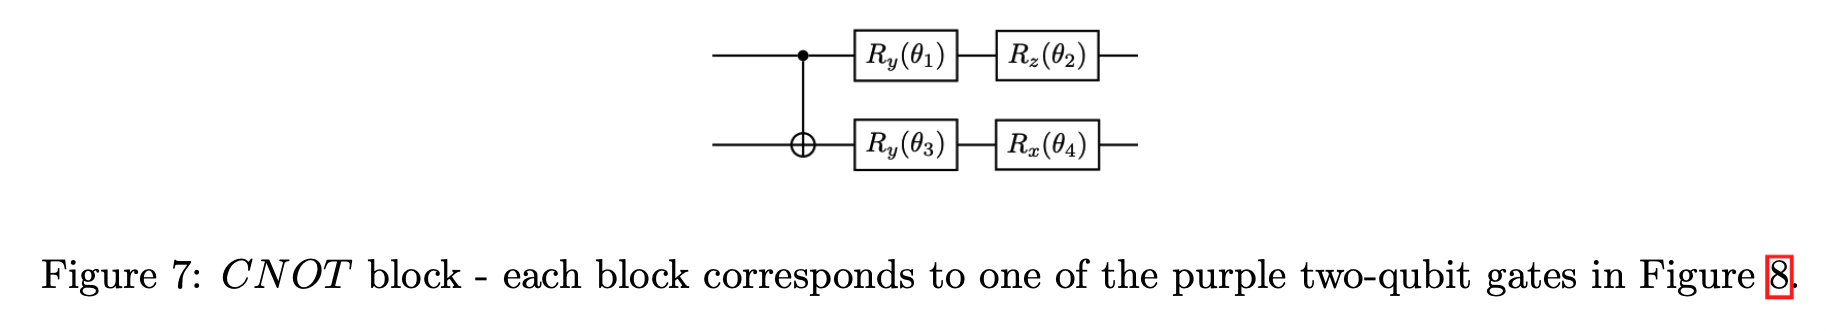



### Fig 8 in the paper
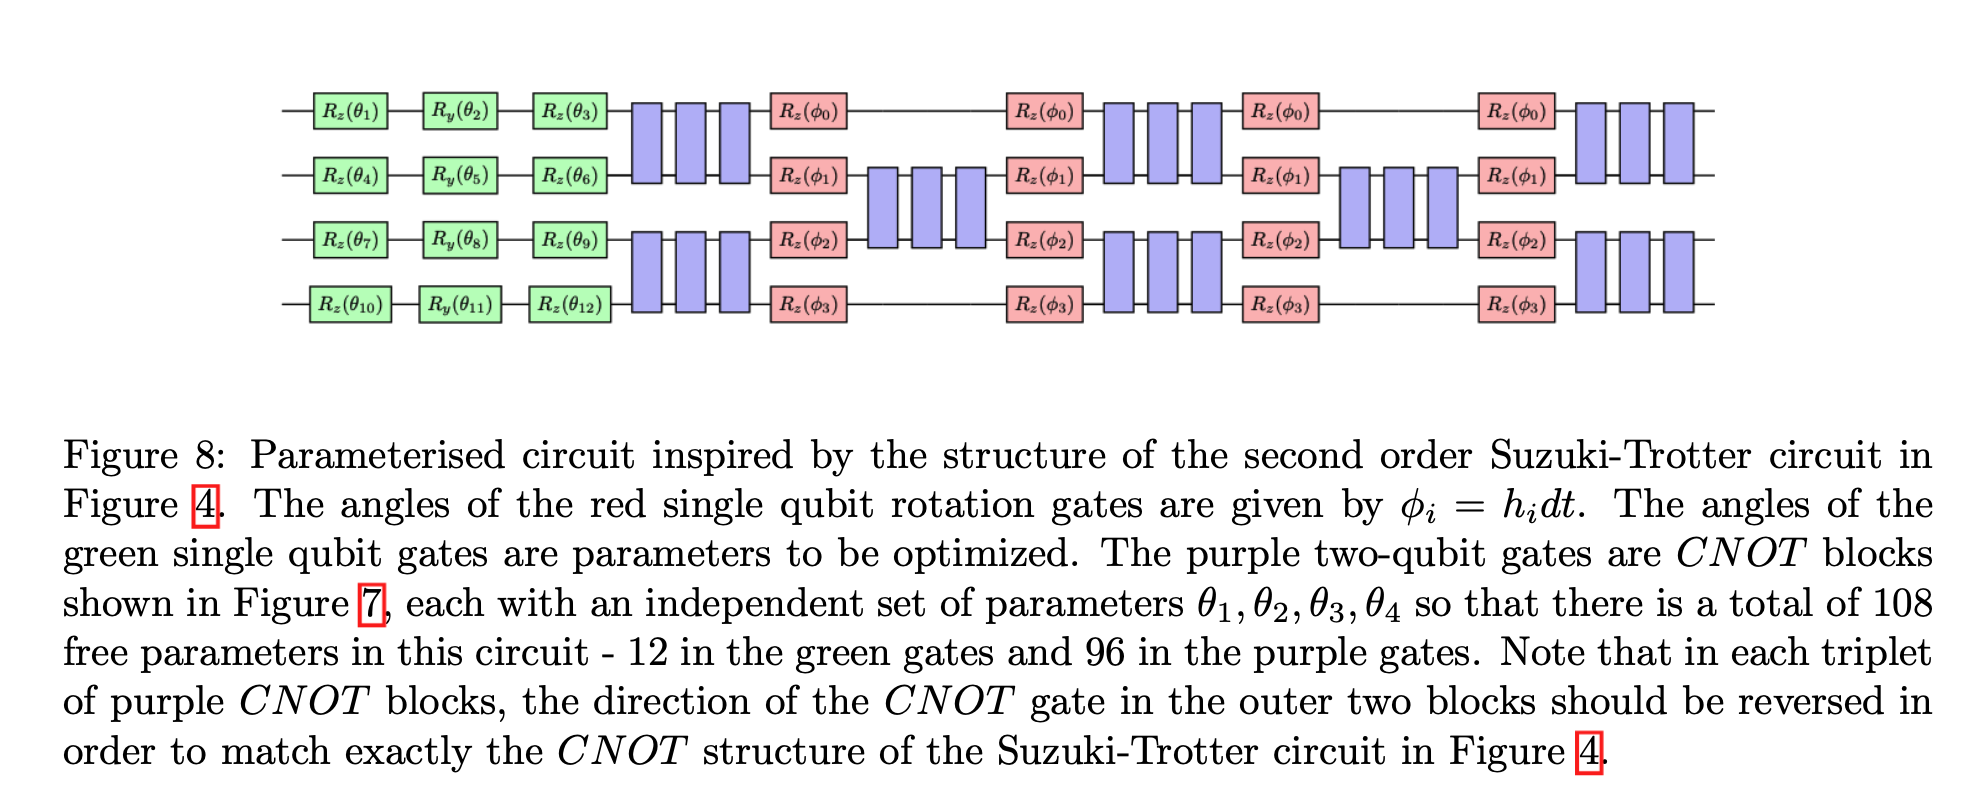

Parametrized AQC circuit for quantum state evolution with H_XYZ:


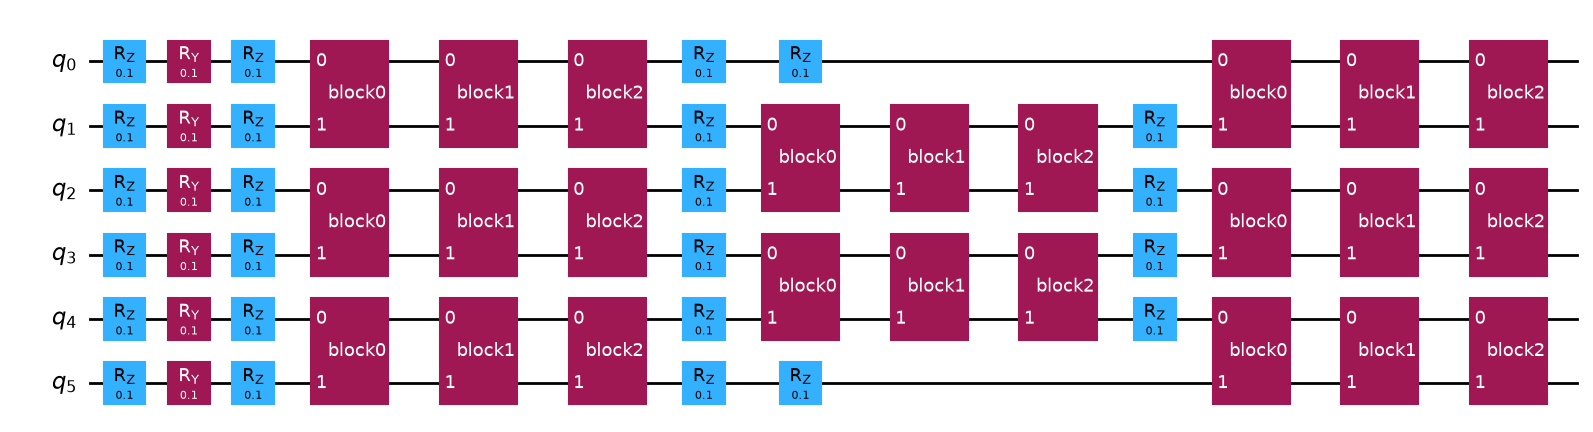

In [5]:
def aqc_cnot_block(theta1, theta2, theta3, theta4, reverse=False):
    qc = QuantumCircuit(2)
    if reverse:
        qc.cx(1, 0)
    else:
        qc.cx(0, 1)
    qc.ry(theta1, 0)
    qc.rz(theta2, 0)
    qc.ry(theta3, 1)
    qc.rx(theta4, 1)
    return qc

def aqc_triplet_block(thetas): # triplet block
    qc = QuantumCircuit(2)
    for block_index, reverse in enumerate([True, False, True]):
        theta1, theta2, theta3, theta4 = thetas[4*block_index: 4*block_index + 4] # we need 4 thetas for each block
        block = aqc_cnot_block(theta1, theta2, theta3, theta4, reverse=reverse).to_gate(label=f"block{block_index}")
        qc.append(block, [0, 1])
    return qc

def aqc_init_layer(L, thetas): # green init layer
    qc = QuantumCircuit(L)
    for q in range(L):
        theta1, theta2, theta3  = thetas[3*q: 3*q + 3] # we need 3 thetas for each qubit
        qc.rz(theta1, q)
        qc.ry(theta2, q)
        qc.rz(theta3, q)
    return qc

def aqc_field_layer(L, thetas): # orange Rz
    qc = QuantumCircuit(L)
    for q in range(L):
        qc.rz(thetas[q], q)
    return qc


def build_aqc_pair_layers(L, steps):
    even_pairs = [(i, i+1) for i in range(0, L-1, 2)]
    odd_pairs = [(i, i+1) for i in range(1, L-1, 2)]

    pair_layers = [even_pairs]
    for step in range(steps):
        pair_layers.append(odd_pairs)
        pair_layers.append(even_pairs)
    
    return pair_layers

def aqc_parametrized_circuit(L, steps, thetas_init, thetas_field, thetas_triplet):
    pair_layers = build_aqc_pair_layers(L, steps)
    qc = QuantumCircuit(L)
    qc.compose(aqc_init_layer(L, thetas_init), range(L), inplace=True)

    triplet_idx = 0
    field_idx = 0
    for layer_idx, pairs in enumerate(pair_layers):
        for i, j in pairs:
            triplet_thetas = thetas_triplet[12*triplet_idx : 12*triplet_idx + 12]
            triplet = aqc_triplet_block(triplet_thetas)
            qc.compose(triplet, [i, j], inplace=True)
            triplet_idx += 1
        if layer_idx < len(pair_layers) - 1:
            field_thetas = thetas_field[L*field_idx : L*field_idx + L]
            qc.compose(aqc_field_layer(L, field_thetas), range(L), inplace=True)
            field_idx += 1

    return qc

print("Parametrized AQC circuit for quantum state evolution with H_XYZ:")
display(aqc_parametrized_circuit(6, steps=1, thetas_init=[0.1]*18, thetas_field=[0.1]*12, thetas_triplet=[0.1]*96).draw('mpl'))


## Step 5 — Trotter-init: a good starting point for training

Translate the Trotter circuit's physics-derived angles directly into AQC-ansatz parameters, so the untrained AQC circuit starts out *identical* to the Trotter circuit (verified exactly below, not approximately). This gives the optimizer a much better starting point than random parameters.

In [6]:
# Trotter circuit and AQC circuit should be equivalent for the same parameters. Let's test this equivalence.

def get_bond_angles(alpha, beta, delta):
    theta = pi/2 - 0.5*delta
    phi = 0.5*alpha -pi/2
    lam = pi/2-0.5*beta
    return theta, phi, lam

def triplet_thetas_from_bond_angles(alpha, beta, delta):
    # For each triplet block, we need to derive the 12 angles from the bond angles
    theta, phi, lam = get_bond_angles(alpha, beta, delta)
    block0 = [0, theta, phi, 0]
    block1 = [0, 0, lam, 0]
    block2 = [0, pi/2, 0, 0]
    return block0 + block1 + block2  # Concatenate the angles for the triplet block

def bottom_qubits(pairs):
    return [j for (i,j) in pairs]


#GOAL: second_order_trotter_circuit and aqc_parametrized_circuit are two different-looking circuits. trotter_init_params is the translator between them — it takes the Trotter circuit's physics settings (alpha, beta, delta, t, steps, h) and works out what numbers to feed into aqc_parametrized_circuit's thetas_init, thetas_field, thetas_triplet so that the AQC circuit becomes the exact same circuit as the Trotter one.

def trotter_aqc_init_params(L, alpha=1, beta=1, delta=1, t=1, steps=1, h=None):

    if h is None:
        h = [0] * L

    dt = t/steps
    pair_layers = build_aqc_pair_layers(L, steps)
    last_layer_idx = len(pair_layers) - 1

    #we ask the bond gate (bottom_qubits(pair_layers[0])) "who needs the -π/2," and we write the answer into the green layer (thetas_init), because the green layer is the only place that rotation can go before the first bond gate starts. 

    thetas_init = [0.0] * (3*L)  # 3 angles per qubit for the initial layer
    for q in bottom_qubits(pair_layers[0]):
        thetas_init[3*q: 3*q + 3] = [-pi/2, 0, 0]  # Rz(-π/2) for the bottom qubits of the first bond layer but implemented in green gates (initial layer)

    thetas_field = []
    thetas_triplet = []

    for layer_idx, pairs in enumerate(pair_layers):
        is_boundary_layer = (layer_idx == 0) or (layer_idx == last_layer_idx)
        layer_dt = dt/2 if is_boundary_layer else dt

        for (i, j) in pairs:
            thetas_triplet += triplet_thetas_from_bond_angles(alpha*layer_dt, beta*layer_dt, delta*layer_dt)

        is_last_layer = (layer_idx == last_layer_idx)
        if not is_last_layer:
            next_bottom_qubits = bottom_qubits(pair_layers[layer_idx + 1])
            for q in range(L):
                angle = h[q] * dt / 2
                if q in next_bottom_qubits:
                    angle -= pi/2
                thetas_field.append(angle)

    return thetas_init, thetas_field, thetas_triplet


def test_trotter_init_params():
    L, alpha, beta, delta, t, steps = 6, 0.7, 1.3, 0.9, 1.0, 2
    h = [0.3, -0.2, 0.5, 0.1, -0.4, 0.2]

    trotter_circuit = second_order_trotter_circuit(L, alpha, beta, delta, t, steps, h)
    thetas_init, thetas_field, thetas_triplet = trotter_aqc_init_params(L, alpha, beta, delta, t, steps, h)
    aqc_circuit = aqc_parametrized_circuit(L, steps, thetas_init, thetas_field, thetas_triplet)

    assert Operator(trotter_circuit).equiv(Operator(aqc_circuit)), "AQC circuit does not match the Trotter circuit after Trotter-init."

test_trotter_init_params()
print("Trotter-init matches the Trotter circuit exactly.")


Trotter-init matches the Trotter circuit exactly.


## Steps 6-8 — cost function, optimizer, and the first real comparison

Pack/unpack all AQC parameters into one flat vector, define the cost as `1 - fidelity` against the exact target state, and train with `scipy.optimize.minimize`. Then compare: does training actually improve on the Trotter-init starting point?

In [10]:
# cost function
# we need to make all aqc circuit parameters in one vector

def theta_vector_length(L, steps):
    pair_layers = build_aqc_pair_layers(L, steps)
    num_layers = len(pair_layers)
    init_gate_length = 3 * L  # 3 angles per qubit for the initial layer
    field_gate_length = L * (num_layers - 1)  # L angles for
    total_pairs = sum(len(pairs) for pairs in pair_layers)
    init_len = 3 * L
    field_len = L * (num_layers - 1)
    triplet_len = 12 * total_pairs
    return init_len, field_len, triplet_len

def pack_thetas(thetas_init, thetas_field, thetas_triplet):
    return np.concatenate([thetas_init, thetas_field, thetas_triplet])

def unpack_thetas(theta_vector, L, steps):
    init_len, field_len, triplet_len =theta_vector_length(L, steps)
    thetas_init = theta_vector[:init_len]
    thetas_field = theta_vector[init_len:init_len+field_len]
    thetas_triplet = theta_vector[init_len + field_len :]
    return thetas_init, thetas_field, thetas_triplet

from qiskit.quantum_info import state_fidelity

def aqc_cost(theta_vector, L, steps, psi0, target_state):
    thetas_init, thetas_field, thetas_triplet = unpack_thetas(theta_vector, L, steps)
    qc = aqc_parametrized_circuit(L, steps, thetas_init, thetas_field, thetas_triplet)
    output_state = psi0.evolve(qc)
    fidelity = state_fidelity(output_state, target_state)
    return 1- fidelity  # we want to minimize 1 - fidelity

from scipy.optimize import minimize

def train_aqc(L, alpha, beta, delta, t, steps, cost_fn=aqc_cost):
    H = get_hamiltonian(L, alpha, beta, delta)
    psi0 = get_Neel_State(L)
    target_state = timeevolution(H, psi0, t)

    thetas_init, thetas_field, thetas_triplet = trotter_aqc_init_params(L, alpha, beta, delta, t, steps)

    theta0 = pack_thetas(thetas_init, thetas_field, thetas_triplet)

    result = minimize(cost_fn, theta0, args=(L, steps, psi0, target_state), method='L-BFGS-B')
    return result

def compare_aqc_vs_trotter(L, alpha, beta, delta, t, steps):
    H = get_hamiltonian(L, alpha, beta, delta)
    psi0 = get_Neel_State(L)
    target_state = timeevolution(H, psi0, t)

    thetas_init, thetas_field, thetas_triplet = trotter_aqc_init_params(L, alpha, beta, delta, t, steps)
    theta0 = pack_thetas(thetas_init, thetas_field, thetas_triplet)
    trotter_cost = aqc_cost(theta0, L, steps, psi0, target_state)

    result = train_aqc(L, alpha, beta, delta, t, steps, cost_fn=aqc_cost)
    trained_cost = result.fun

    print(f"steps={steps}: Trotter cost = {trotter_cost:.6f}  |  trained AQC cost = {trained_cost:.6f}")
    return trotter_cost, trained_cost

#compare_aqc_vs_trotter(L=6, alpha=1.0, beta=1.0, delta=1.0, t=1.0, steps=2)
compare_aqc_vs_trotter(L=6, alpha=1.0, beta=1.0, delta=1.0, t=3.0, steps=2)

010101
010101
steps=2: Trotter cost = 0.072774  |  trained AQC cost = 0.001501


(0.07277420551537062, 0.0015010030043577371)

## Step 9 — scaling the cost function: MPS-native overlap

`state_fidelity` and building the full target `Statevector` both require `2^L` numbers — fine at `L=6`, impossible at large `L`. Here we build an MPS-based equivalent (`statevector_to_mps`, `mps_overlap`) and confirm it matches the exact fidelity calculation exactly, before relying on it at scale.

In [8]:
# impl MPS method
def statevector_to_mps(state, L):
    tensors=[]
    M = np.array(state, dtype=complex).reshape(2, -1)
    left_bond = 1

    for q in range(L-1):
        U, S, Vt = np.linalg.svd(M, full_matrices=False)
        new_bond = len(S)
        tensors.append(U.reshape(left_bond, 2, new_bond))
        M = (np.diag(S)@Vt).reshape(new_bond*2, -1)
        left_bond = new_bond

    tensors.append(M.reshape(left_bond, 2, 1))
    return tensors    

def mps_to_statevector(tensors):
    result = tensors[0]
    for tensor in tensors[1:]:
        result = np.tensordot(result, tensor, axes=([-1],[0]))
    return result.reshape(-1) # flatten to single flat list

def test_statevector_to_mps():
    L=6
    psi = timeevolution(get_hamiltonian(L), get_Neel_State(L), 1.0).data
    tensors = statevector_to_mps(psi, L)
    psi_reconstructed = mps_to_statevector(tensors)
    assert np.allclose(psi, psi_reconstructed), "MPS conversion failed to reconstruct the original statevector."
    print("MPS conversion test passed.")

# axes=([0],[0]) contracts E's axis 0 against A's axis 0 -- not because
# tensordot always works that way (plain A @ B contracts A's LAST axis
# against B's FIRST axis, which for 2D arrays happens to be [1],[0]),
# but because every psi-tensor was built with its left bond at axis 0,
# and E's axis 0 always tracks "how far we've absorbed into psi's chain"
# -- at this point that's the exact same connection as A's left bond.

def mps_overlap(tensors_psi, tensors_phi):
    E = np.ones((1,1), dtype=complex)
    for A, B in zip(tensors_psi, tensors_phi):
        Bc = np.conj(B)
        E = np.tensordot(E, A, axes=([0], [0]))
        E = np.tensordot(E, Bc, axes=([0,1], [0,1]))
    return E[0,0]

def test_mps_overlap():
    L = 6
    psi = timeevolution(get_hamiltonian(L), get_Neel_State(L), 1.0).data
    phi = get_Neel_State(L).data

    tensors_psi = statevector_to_mps(psi, L)
    tensors_phi = statevector_to_mps(phi, L)

    overlap = mps_overlap(tensors_psi, tensors_phi)
    exact = np.vdot(phi, psi)

    assert np.isclose(overlap, exact), "MPS overlap did not match the exact inner product."
    print("MPS overlap matches the exact inner product:", overlap)

test_statevector_to_mps()
test_mps_overlap()

def aqc_cost_using_mps(theta_vector, L, steps, psi0, target_state):
    thetas_init, thetas_field, thetas_triplet = unpack_thetas(theta_vector, L, steps)
    qc = aqc_parametrized_circuit(L, steps, thetas_init, thetas_field, thetas_triplet)
    output_state = psi0.evolve(qc)

    tensors_aqc_output = statevector_to_mps(output_state.data, L)
    tensors_target = statevector_to_mps(target_state.data, L)
    overlap = mps_overlap(tensors_aqc_output, tensors_target)
    fidelity = np.abs(overlap)**2
    return 1 - fidelity  # we want to minimize 1 - fidelity

# test train method separately
result_exact = train_aqc(6, 0.7, 1.3, 0.9, 1.0, 1, cost_fn=aqc_cost)
result_mps = train_aqc(6, 0.7, 1.3, 0.9, 1.0, 1, cost_fn=aqc_cost_using_mps)

print("exact cost:", result_exact.fun)
print("mps cost:  ", result_mps.fun)


010101
MPS conversion test passed.
010101
010101
MPS overlap matches the exact inner product: (0.05270764681662424-0.5252545686820473j)
010101
010101
exact cost: 8.484745229986324e-05
mps cost:   8.553780820230727e-05


## Step 10 — TEBD: building the target state at scale

1. We're going to build a **TEBD state** — a state built directly as an MPS, gate by gate — which becomes our **target state** for larger `L`.
2. Separately, we'll build and train an **AQC circuit** (seeded via Trotter-init, same as before), using the TEBD state as the target to compare against — the TEBD state is what lets us find a *shallow* AQC circuit that reproduces it.
3. We need the TEBD state because once `L` gets large, we can no longer build an exact `Statevector` — it would need `2^L` numbers. TEBD computes the same kind of "true answer" but as an MPS, which stays small even when `L` is big.

This is **Algorithm 1, step 1** from the paper: *"Apply classical algorithm (e.g. TEBD) to generate state |ψ(t)⟩."*

In [9]:
def get_Neel_State_as_mps(L):
    bit0 = np.array([[[1],[0]]]) # shape (1,2,1) for the first qubit in the Neel state this is |0> in tensor form. Centre shape 2 always represents 2 possible states ie 0 or 1
    bit1 = np.array([[[0], [1]]]) # shape (1,2,1) for the first qubit in the Neel state this is |1> in tensor form
    return [bit0 if q%2==0 else bit1 for q in range(L)]


#An MPS tensor for one site has shape (left_bond, 2, right_bond) — axis 1 (the middle one, size 2) is the "physical" axis, meaning: this is where the qubit's actual |0⟩/|1⟩ information lives. A 1-qubit gate is just a 2×2 matrix that's supposed to act on that |0⟩/|1⟩ information and nothing else — left_bond and right_bond are just bookkeeping connections to the neighboring sites and must be left completely alone. So apply a 1-qubit gate to one MPS tensor means: for every combination of left_bond and right_bond index, take the little length-2 vector sitting there, and multiply it by the gate matrix. Thats it — same operation, repeated at every (left, right) position.

#X|0⟩ means we contract col of X with col of the vector state |0> in this case

# tensordot(gate, inputtensor, axes=([1],[1])) contracts gate's columns (input)
# against inputtensor's physical axis, leaving gate's rows (output) out front:
# for a (4,2,5) tensor this gives raw shape (2,4,5) = (physical, left, right) --
# so tranpose makes it to (4,2,5) again.
# reshape(4,2,5) looks like it should do the same job but doesn't: it just
# re-chops the same flat memory order, so fixed[0,1,3] would come out as 18
# (someone else's value) instead of 3 -- verified, reshape != transpose here.

def apply_1q_gate_to_mps_tensor(inputtensor, gate):
    return np.tensordot(gate, inputtensor, axes=([1],[1])).transpose(1, 0, 2)

def apply_2q_gate_mps_tensor(inputtensor1, inputtensor2, gate, max_bond=None):
    mergedtoonetensor = np.tensordot(inputtensor1, inputtensor2, axes=([2], [0]))
    gate_tensor = gate.reshape(2,2,2,2) # 4 by 4 2 qubit matrix flattened. each axis has 2 states so it can represent the value of 00, 01, 10, 11 CNOT below is an e.g.
    '''         col=0  col=1  col=2  col=3
        row=0 [   1      0      0      0  ]
        row=1 [   0      1      0      0  ]
        row=2 [   0      0      0      1  ]
        row=3 [   0      0      1      0  ]
    '''
    gateappliedtensor = np.tensordot(gate_tensor, mergedtoonetensor, axes =([2,3],[1,2]))
    result = gateappliedtensor.transpose(2, 0, 1, 3)
    l, _, _, r = result.shape
    matrix = result.reshape(l*2, 2*r)
    U, S, Vt = np.linalg.svd(matrix, full_matrices=False)

    if max_bond is not None:
        k = min(max_bond, len(S)) # note S is a 1-D list of numbers at the point
        U, S, Vt = U[:, :k], S[:k], Vt[:k, :]

    new_bond = len(S)
    new_tensor1 = U.reshape(l,2,new_bond)
    new_tensor2 = (np.diag(S) @Vt).reshape(new_bond, 2, r)
    return new_tensor1, new_tensor2


def circuit_to_mps_tensors(start_tensors, circuit, max_bond=None):
    start_tensors = list(start_tensors)
    L = circuit.num_qubits
    for instruction in circuit.data:
        gate_matrix = Operator(instruction.operation).data
        qubits = [circuit.find_bit(q).index for q in instruction.qubits] # instruction.qubits gives you Qubit objects, not plain numbers instruction.qubits = (Qubit(index=3), Qubit(index=2))
        if len(qubits) == 1:
            tensor_idx = L -1 -qubits[0]
            start_tensors[tensor_idx] = apply_1q_gate_to_mps_tensor(start_tensors[tensor_idx], gate_matrix)
        else:
            qubitA, qubitB = qubits
            tensor_idx_A = L -1 - qubitA
            tensor_idx_B = L -1 - qubitB
            if tensor_idx_B < tensor_idx_A:
                lo, hi, gate_to_use = tensor_idx_B, tensor_idx_A, gate_matrix
            else:
                lo, hi = tensor_idx_A, tensor_idx_B
                gate_to_use = gate_matrix.reshape(2,2,2,2).transpose(1,0,3,2).reshape(4,4)
            start_tensors[lo], start_tensors[hi] = apply_2q_gate_mps_tensor(start_tensors[lo], start_tensors[hi], gate_to_use, max_bond=max_bond)
    return start_tensors

def testTEBD_vs_exact():
    L, alpha, beta, delta, t, steps = 12, 0.7, 1.3, 0.9, 1.0, 6

    H_XYZ = get_hamiltonian(L, alpha, beta, delta)
    psi0 = get_Neel_State(L)
    exact_target = timeevolution(H_XYZ, psi0, t)

    trotter_qc = second_order_trotter_circuit(L, alpha, beta, delta, t, steps)
    tebd_tensors = circuit_to_mps_tensors(get_Neel_State_as_mps(L), trotter_qc) # not passing max_bond which means no truction so we can test against exact

    exact_tensors = statevector_to_mps(exact_target.data, L)
    fidelity = np.abs(mps_overlap(tebd_tensors, exact_tensors))**2
    print(f"TEBD (no truncation, {steps} Trotter steps) vs exact diagonalization fidelity: {fidelity:.8f}")
    
testTEBD_vs_exact()


def run_TEBD_at_scale():
    print("Running L=50 TEBD now...")
    L, alpha, beta, delta, t, steps, max_bond = 50, 0.7, 1.3, 0.9, 1.0, 10, 32
    
    trotter_qc = second_order_trotter_circuit(L, alpha, beta, delta, t, steps)
    tebd_tensors = circuit_to_mps_tensors(get_Neel_State_as_mps(L), trotter_qc, max_bond) 
    
    bond_dims = [tsr.shape[0] for tsr in tebd_tensors[1:]]
    
    print(f"L={L}, steps={steps}, max_bond={max_bond}: max bond dimension reached = {max(bond_dims)}")
    print("bond dimensions along the chain:", bond_dims)

run_TEBD_at_scale()


010101010101
TEBD (no truncation, 6 Trotter steps) vs exact diagonalization fidelity: 0.99998485
Running L=50 TEBD now...
L=50, steps=10, max_bond=32: max bond dimension reached = 32
bond dimensions along the chain: [2, 4, 8, 16, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 16, 8, 4, 2]


## Next steps — making the whole pipeline actually run at scale (DONE, see Steps 11-14 below)

11. ✅ **Make the AQC circuit's own output MPS-native** — `aqc_cost_tebd_mps`.
12. ✅ **Rewire training to take a TEBD-built MPS target** instead of exact diagonalization — `train_aqc_mps_at_scale`.
13. ✅ **Run training end-to-end at `L=50`** — fidelity 0.999495, see Step 13 below.
14. ⬜ **(Paper's Algorithm 1, step 3)** append `k` additional Trotter steps onto the trained circuit — see Step 14 below, not yet started.

## Step 11 — a fully MPS-native cost function

`aqc_cost_using_mps` (Step 9) still calls `psi0.evolve(qc)` — a full `Statevector` simulation of the AQC circuit — before ever converting to MPS, which is exactly what breaks at large `L`. Here we build the AQC circuit's output *directly* as an MPS, reusing `circuit_to_mps_tensors` (already built and verified for Step 10's Trotter circuit) on the AQC ansatz circuit instead. This one new function, `aqc_cost_using_mps_native`, never touches a full statevector at any point.

## Step 12 — training driver with no exact diagonalization

`train_aqc_mps_at_scale` takes `target_tensors` as an argument instead of building it internally via `get_hamiltonian`/`timeevolution` (impossible at large `L`) — the caller is expected to build the target via TEBD (Step 10) first. Confirmed: neither `get_hamiltonian` nor `timeevolution` appear anywhere in this function. (Both this function and Step 11's `aqc_cost_tebd_mps` are typed into the single code cell below.)

In [13]:
def aqc_cost_tebd_mps(theta_vector, L, steps, psi0_mps, target_tensors, max_bond=None):
    thetas_init, thetas_field, thetas_triplet = unpack_thetas(theta_vector, L, steps)
    aqc_circuit = aqc_parametrized_circuit(L, steps, thetas_init, thetas_field, thetas_triplet)
    aqc_tensors = circuit_to_mps_tensors(psi0_mps, aqc_circuit, max_bond)
    overlap = mps_overlap(aqc_tensors, target_tensors)
    fidelity = np.abs(overlap)**2
    return 1- fidelity


def train_aqc_mps_at_scale(L, alpha, beta, delta, t, steps, target_tensors, max_bond=None, cost_fn=None):
    psi0_mps = get_Neel_State_as_mps(L)
    thetas_init, thetas_field, thetas_triplet = trotter_aqc_init_params(L, alpha, beta, delta, t, steps)
    packed_theta_vector = pack_thetas(thetas_init, thetas_field, thetas_triplet)
    result = minimize(cost_fn, packed_theta_vector, args=(L, steps, psi0_mps, target_tensors, max_bond), method='L-BFGS-B' )
    return result


## Step 13 — run training end-to-end at scale (Algorithm 1, complete)

Everything above comes together here: build the TEBD target at `L=50` (`steps_tebd=10`, `max_bond=32`), then train a much shallower AQC ansatz (`steps_aqc=2`, 1826 parameters) against it — no exact diagonalization, no full `Statevector`, anywhere in the pipeline.

**Result: fidelity = 0.999495** (cost = 0.000505). The trained circuit has depth 22 and 369 two-qubit gates, versus the much deeper Trotter target — a real compression, not a trivial match (Trotter-init alone does *not* start at this fidelity, since `steps_aqc≠steps_tebd`).

This completes Algorithm 1's steps 1-2 (build target, train ansatz). Step 14 below is the paper's final step.

In [14]:
L, alpha, beta, delta, t, steps_tebd, max_bond, steps_aqc = 50, 0.7, 1.3, 0.9, 1.0, 10, 32, 2
    
trotter_qc = second_order_trotter_circuit(L, alpha, beta, delta, t, steps_tebd)
tebd_tensors = circuit_to_mps_tensors(get_Neel_State_as_mps(L), trotter_qc, max_bond) 

result = train_aqc_mps_at_scale(L, alpha, beta, delta, t, steps_aqc, tebd_tensors,max_bond, aqc_cost_tebd_mps)
print(f"L={L}: trained AQC cost (steps_aqc={steps_aqc}) vs TEBD target (steps_tebd={steps_tebd}) = {result.fun:.6f} and fidelity is = {1-result.fun:.6f}")

L=50: trained AQC cost (steps_aqc=2) vs TEBD target (steps_tebd=10) = 0.000505 and fidelity is = 0.999495


In [17]:
from datetime import datetime

save_filename = f"trained_aqc_L{L}_stepsaqc{steps_aqc}_stepstebd{steps_tebd}_{datetime.now().strftime('%Y%m%d_%H%M')}.npz"

np.savez(save_filename,
         theta=result.x,
         L=L, steps_aqc=steps_aqc, steps_tebd=steps_tebd,
         alpha=alpha, beta=beta, delta=delta, t=t, max_bond=max_bond,
         fidelity=1-result.fun,
         saved_at=datetime.now().strftime("%I:%M %p on %B %d, %Y"),
         trotter_depth=trotter_qc.depth(),
         trotter_size=trotter_qc.size(),
         trotter_size_decomposed=trotter_qc.decompose().size())
print(f"saved trained parameters to {save_filename}")

saved = np.load(save_filename)
theta_loaded = saved['theta']
L, steps_aqc = int(saved['L']), int(saved['steps_aqc'])
print(f"loaded {len(theta_loaded)} trained parameters, fidelity was {float(saved['fidelity']):.6f}, saved at {saved['saved_at']}")

saved trained parameters to trained_aqc_L50_stepsaqc2_stepstebd10_20260914_1450.npz
loaded 1826 trained parameters, fidelity was 0.999495, saved at 02:50 PM on September 14, 2026


In [18]:
thetas_init, thetas_field, thetas_triplet = unpack_thetas(theta_loaded, L, steps_aqc)
trained_circuit = aqc_parametrized_circuit(L, steps_aqc, thetas_init, thetas_field, thetas_triplet)

print(f"trained circuit depth: {trained_circuit.depth()}")
print(f"trained circuit size (top-level instructions): {trained_circuit.size()}")
print(f"trained circuit size (decomposed into elementary gates): {trained_circuit.decompose().size()}")
print(f"gate counts (decomposed): {dict(trained_circuit.decompose().count_ops())}")

print()
print("=== Trotter target vs trained AQC circuit ===")
print(f"Trotter  (steps_tebd={steps_tebd}): depth = {trotter_qc.depth()}, size = {trotter_qc.size()}, decomposed size = {trotter_qc.decompose().size()}")
print(f"Trained  (steps_aqc={steps_aqc}):  depth = {trained_circuit.depth()}, size = {trained_circuit.size()}, decomposed size = {trained_circuit.decompose().size()}")
print(f"compression: {trotter_qc.decompose().size() / trained_circuit.decompose().size():.1f}x fewer gates, {trotter_qc.depth() / trained_circuit.depth():.1f}x shallower")

trained circuit depth: 22
trained circuit size (top-level instructions): 719
trained circuit size (decomposed into elementary gates): 2195
gate counts (decomposed): {'ry': 738, 'cx': 369, 'rz': 369, 'rx': 369, 'p': 300, 'r': 50}

=== Trotter target vs trained AQC circuit ===
Trotter  (steps_tebd=10): depth = 41, size = 1515, decomposed size = 5120
Trained  (steps_aqc=2):  depth = 22, size = 719, decomposed size = 2195
compression: 2.3x fewer gates, 1.9x shallower


## Step 14 — append `k` additional Trotter steps (Algorithm 1, step 3) — NOT STARTED

**What's left:** the trained circuit `V(theta0)` above only approximates evolution up to time `t`. The paper's last step is to append `k` more exact Trotter steps *on top of* the trained circuit, extending the reachable time further while keeping most of the circuit shallow (only the appended tail grows with time).

**Why this is valid** (to walk through properly before coding): each appended Trotter step is itself a unitary — applying it composes two unitary evolutions, `U_trotter · V(theta0)`, which doesn't destroy the fidelity already achieved by `V(theta0)`; it extends what state is being represented, rather than degrading the existing approximation.

**What needs writing:** one function that takes the trained circuit (rebuilt from `result.x`, see Step 13) plus `k` and the physics params, and returns `trained_circuit.compose(second_order_trotter_circuit(...))` — appending `k` fresh Trotter steps after the existing gates. Needs a verification cell too (does composing extend fidelity to a later target time correctly).